<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
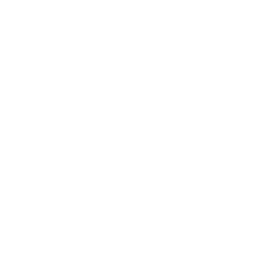
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Flagging Outlier Schools with Analysis of Means</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Education / Performance Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A regional education authority wants to know which schools in a district post
math results that genuinely stand apart from the district average — not just
the highest and lowest by rank, but those that exceed what sampling variation
alone would explain. Analysis of Means (ANOM) answers exactly that question:
it compares each group mean against the grand mean and draws upper and lower
decision limits, flagging any school whose mean falls outside them.

This notebook builds a balanced 8-school cohort (12 pupils each, 96 records),
runs **PROC ANOM** with an XCHART at `ALPHA=0.05`, and feeds the flagged
schools into **PROC UNIVARIATE** for a normality check. ANOM flags **three**
schools relative to a grand mean of **499.08**: **SCH-02** (mean 532.58) and
**SCH-07** (mean 529.17) sit above the upper decision limit of **517.93**,
while **SCH-05** (mean 460.75) falls below the lower limit of **480.23**. The
remaining five schools stay within the limits and are statistically
indistinguishable from the district average.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------:|
| WORK.SCHOOL_SCORES | Pupil-level math test scores, 8 schools | 96 |

The cohort is synthetic but realistic: each school enrols 12 pupils whose
scores are drawn from a normal distribution centred near the district target
of 500 (SD 22). Three schools are given a deliberate shift — two above and one
below — so the analysis has genuine signals to detect.

---

In [1]:
/* --------------------------------------------------------
   Generate a balanced 8-school cohort, 12 pupils each (96
   records, within the 100-observation cap). Schools 2 and
   7 are shifted up; school 5 is shifted down, so ANOM has
   real out-of-limit signals to detect.
   -------------------------------------------------------- */
data work.school_scores;
    call streaminit(2026);
    do school = 1 to 8;
        school_name = cat('SCH-', put(school, z2.));
        shift = 0;
        if school = 2 then shift = 34;
        if school = 5 then shift = -38;
        if school = 7 then shift = 30;
        do pupil = 1 to 12;
            math_score = round(rand('normal', 500 + shift, 22), 1);
            output;
        end;
    end;
    keep school_name math_score;
run;

NOTE: DATA work.school_scores


NOTE: Wrote work.school_scores (96 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

### Per-school baseline

Before running ANOM, summarise each school's math scores. The means range from
about 461 to 533, but raw means alone cannot tell us which gaps are real and
which are sampling noise — that is what the decision limits decide next.

In [2]:
/* --------------------------------------------------------
   Per-school summary of math scores
   -------------------------------------------------------- */
proc means data=work.school_scores n mean std min max maxdec=1;
    class school_name;
    var math_score;
    title 'Per-School Math Score Summary';
run;

                                             Per-School Math Score Summary                                              

                                                  The MEANS Procedure

                                             Analysis Variable : math_score

        school_name          N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------
        SCH-01                  12          499.6           26.7          464.0          554.0
        SCH-02                  12          532.6           27.7          491.0          579.0
        SCH-03                  12          485.8           18.1          461.0          513.0
        SCH-04                  12          490.0           23.4          441.0          519.0
        SCH-05                  12          460.8           20.9          441.0          514.0
        SCH-06                  12          497.9           20.8 

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Analysis of Means

PROC ANOM compares each school's mean against the grand mean and computes upper
(UDL) and lower (LDL) decision limits at `ALPHA=0.05`. A school is flagged only
if its mean crosses a limit — the same idea as a control chart, but for
comparing group means simultaneously while holding the family-wise error rate
at 5%. The XCHART plots every school mean against those limits; flagged schools
are highlighted.

                                             Per-School Math Score Summary                                              


                    The ANOM Procedure
                    Analysis of Means for Math Score

  Alpha:            0.0500
  Number of groups: 8
  Grand mean:       499.083333
  MSE:              624.159091

  Group                N       Mean        UDL        LDL     Flag
  -----------------------------------------------------------------
  SCH-01              12   499.5833   517.9339   480.2328         
  SCH-02              12   532.5833   517.9339   480.2328    ABOVE
  SCH-03              12   485.8333   517.9339   480.2328         
  SCH-04              12   490.0000   517.9339   480.2328         
  SCH-05              12   460.7500   517.9339   480.2328    BELOW
  SCH-06              12   497.9167   517.9339   480.2328         
  SCH-07              12   529.1667   517.9339   480.2328    ABOVE
  SCH-08              12   496.8333   517.9339   480.2328         



NOTE: PROC ANOM data=work.school_scores

NOTE: ODS plot written: anom_math_score.spec.json
NOTE: PROC ANOM statement used (96 observations read).
NOTE: ANOM decision limits use Bonferroni-Sidak approximation (conservative). True ANOM uses equicoordinate multivariate t-distribution.


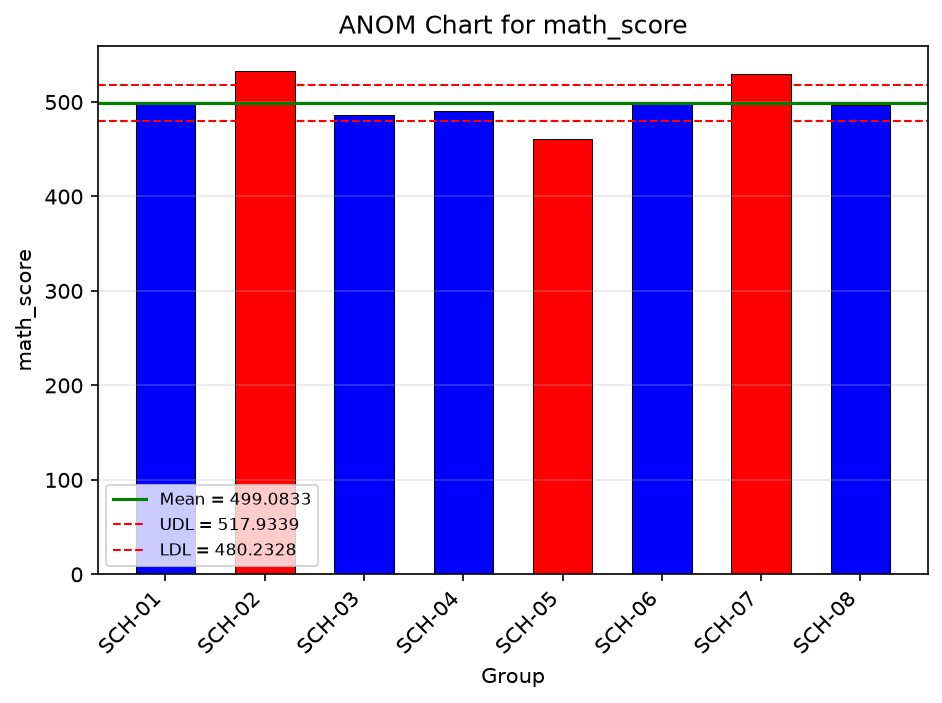

In [3]:
/* --------------------------------------------------------
   PROC ANOM XCHART: test each school mean against the
   grand mean at ALPHA=0.05. OUTTABLE captures the per-school
   means, decision limits, and exceed-limit flags.
   -------------------------------------------------------- */
proc anom data=work.school_scores;
    xchart math_score * school_name /
        alpha=0.05
        outtable=work.anom_table;
    label math_score = 'Math Score'
          school_name = 'School';
    title 'ANOM: School Math Performance vs District Mean';
run;

---

### Capturing the flagged schools

The OUTTABLE dataset carries one row per school with its mean (`_SUBX_`), the
decision limits (`_LDLX_`, `_UDLX_`), and an `_EXLIM_` flag set to `ABOVE` or
`BELOW` when the school is out of limits. Selecting the flagged rows gives the
schools that warrant a closer look.

In [4]:
/* --------------------------------------------------------
   Keep only schools flagged outside the decision limits
   -------------------------------------------------------- */
data work.outlier_schools;
    set work.anom_table;
    where _exlim_ ne ' ';
    keep school_name _subx_ _exlim_;
run;

proc print data=work.outlier_schools noobs;
    var school_name _subx_ _exlim_;
    title 'Schools Outside the ANOM Decision Limits';
run;

                                        Schools Outside the ANOM Decision Limits                                        

SCHOOL_NAME      _SUBX_  _EXLIM_
SCH-02       532.583333  ABOVE
SCH-05           460.75  BELOW
SCH-07       529.166667  ABOVE



NOTE: DATA work.outlier_schools


NOTE: Read 8 rows from work.anom_table.
NOTE: Wrote work.outlier_schools (3 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.outlier_schools

NOTE: PROC PRINT completed: 3 observations printed, 3 variables


---

### Diagnostics for the flagged schools

ANOM's decision limits assume the underlying scores are approximately normal.
Before acting on the flags, check that assumption at each flagged school with
PROC UNIVARIATE's Shapiro-Wilk test.

In [5]:
/* --------------------------------------------------------
   Merge the flagged-school list back to pupil scores and
   run distributional diagnostics on each flagged school.
   -------------------------------------------------------- */
proc sort data=work.school_scores; by school_name; run;
proc sort data=work.outlier_schools; by school_name; run;

data work.outlier_scores;
    merge work.school_scores (in=a)
          work.outlier_schools (in=b);
    by school_name;
    if a and b;
run;

proc univariate data=work.outlier_scores normal;
    class school_name;
    var math_score;
    histogram math_score / normal;
    title 'Distributional Diagnostics for Flagged Schools';
run;

                                     Distributional Diagnostics for Flagged Schools                                     

                        school_name=SCH-02

                                                The UNIVARIATE Procedure
                                                 Variable:  math_score

                                                        Moments

N                                 12    Sum Weights                       12
Mean                      532.583333    Sum Observations         6391.000000
Std Deviation              27.655209    Variance                  764.810606
Skewness                    0.074859    Kurtosis                   -0.713041
Uncorrected SS        3412153.000000    Corrected SS             8412.916667
Coeff Variation             5.192654    Std Error Mean              7.983371

          Basic Statistical Measures           

Location              Variability              
--------  ----------  -------------  ----------
Mean      532.58

NOTE: PROC SORT data=work.school_scores

NOTE: Read 96 rows from work.school_scores.
NOTE: Wrote work.school_scores (96 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.outlier_schools

NOTE: Read 3 rows from work.outlier_schools.
NOTE: Wrote work.outlier_schools (3 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.outlier_scores

NOTE: Stream 1 processed 96 rows, max BY-group size: 12 (O(1) memory verified)
NOTE: Stream 2 processed 3 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.outlier_scores (36 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC UNIVARIATE


---

### Interpretation

The ANOM XCHART flags **three** of the eight schools against a grand mean of
**499.08** (UDL **517.93**, LDL **480.23**):

- **SCH-02** — mean **532.58**, above the upper decision limit.
- **SCH-07** — mean **529.17**, above the upper decision limit.
- **SCH-05** — mean **460.75**, below the lower decision limit.

The other five schools (SCH-01, SCH-03, SCH-04, SCH-06, SCH-08) fall inside the
limits; their differences from the district average are within what sampling
variation alone would produce, so no action is warranted.

The PROC UNIVARIATE normality check qualifies the flags. The two high
performers are cleanly normal — SCH-02 (Shapiro-Wilk W **0.966**, p **0.860**)
and SCH-07 (W **0.967**, p **0.883**) — so their elevated means are trustworthy
signals. The low performer **SCH-05**, however, fails the normality test
(W **0.803**, p **0.010**, skewness **1.76**): its distribution is
right-skewed, with most pupils low but a few near the district norm. That is a
useful caveat — SCH-05's shortfall is real, but it is driven by a concentrated
group of struggling pupils rather than a uniform shift, which points toward
targeted intervention rather than a whole-school programme.

ANOM delivers what a simple ranking cannot: it separates the three schools that
genuinely differ from the district average from the five that only appear to,
and it does so with a single chart that a district leadership team can read at
a glance.

---

In [6]:
/* --------------------------------------------------------
   Export the per-school ANOM results (means, decision
   limits, and flags) for district leadership.
   -------------------------------------------------------- */
proc export data=work.anom_table
    outfile='school_anom_results.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.anom_table outfile=school_anom_results.csv

NOTE: Exported 8 rows to school_anom_results.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>